# Part A — EDA and Missing Values

**Project:** Academy Nova Course Cancellation Prediction  
**Group:** 51  
**Main metric:** ROC-AUC  

This notebook covers the first project section: exploratory data analysis and missing-value analysis.

The goal of this stage is to understand the dataset before modeling, identify meaningful patterns, detect data-quality issues, compare train and test distributions, and decide how missing values should be handled.

Important project principles:
- The test set must never be used for fitting preprocessing steps.
- Every visualization should have a purpose.
- EDA conclusions should directly support feature engineering and modeling decisions.
- Missing-value treatment should be justified using the data and business logic.

In [90]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.feature_selection import mutual_info_classif

# Make project src importable from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import ID_COL, TARGET_COL, RANDOM_STATE
from src.data_loading import load_raw_data, validate_raw_data

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE

42

## 1. Load and Validate the Raw Data

Before starting EDA, we validate the basic structure of the train and test datasets.  
This prevents common project mistakes such as using the wrong file, accidentally fitting on the test target, duplicate IDs, or column mismatches between train and test.

In [91]:
train_df, test_df = load_raw_data()
validate_raw_data(train_df, test_df)

Validating raw data...
Raw data validation passed.
Train shape: (63464, 29)
Test shape: (15866, 28)
Target positive rate: 0.4144


## 2. Dataset Overview

We first inspect the dataset dimensions, column types, and the role of each column.  
This gives us a map of the problem before deeper analysis.

In [92]:
overview = pd.DataFrame({
    "column": train_df.columns,
    "dtype": train_df.dtypes.astype(str).values,
    "missing_count": train_df.isna().sum().values,
    "missing_pct": (train_df.isna().mean().values * 100).round(2),
    "unique_values": train_df.nunique(dropna=True).values
})

overview

,column,dtype,missing_count,missing_pct,unique_values
0,Client_ID,int64,0,0.00,63464
1,Professionals_Count,int64,0,0.00,5
2,Students_Count,float64,4,0.01,5
3,Observers_Count,int64,0,0.00,5
4,Course_Start_Date,object,0,0.00,666
5,Practical_Hours,int64,0,0.00,18
6,Theory_Hours,int64,0,0.00,29
7,Registration_Days_Before,float64,2666,4.20,423
8,Origin_Country,object,557,0.88,721
9,Catering_Package,object,407,0.64,321


In [93]:
numeric_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = train_df.select_dtypes(include=["object"]).columns.tolist()

numeric_features = [col for col in numeric_cols if col not in [ID_COL, TARGET_COL]]
categorical_features = categorical_cols.copy()

print(f"Number of rows in train: {train_df.shape[0]}")
print(f"Number of rows in test: {test_df.shape[0]}")
print(f"Number of numeric features: {len(numeric_features)}")
print(f"Number of categorical/date features: {len(categorical_features)}")

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical/date features:")
print(categorical_features)

Number of rows in train: 63464
Number of rows in test: 15866
Number of numeric features: 16
Number of categorical/date features: 11

Numeric features:
['Professionals_Count', 'Students_Count', 'Observers_Count', 'Practical_Hours', 'Theory_Hours', 'Registration_Days_Before', 'Prev_Course_Dropouts', 'Prev_Course_Attended', 'Pre_Course_Supports_Tickets', 'Physical_Course_Kits', 'Waiting_List_Days', 'Registration_Changes', 'Returning_Client', 'Agent_ID', 'Company_ID', 'Daily_Tuition_Cost']

Categorical/date features:
['Course_Start_Date', 'Origin_Country', 'Catering_Package', 'Welcome_Gift_Type', 'Requested_Lab_Config', 'Assigned_Lab_Config', 'Enrollment_Type', 'Lanyard_Color', 'Client_Category', 'Submission_Source', 'Payment_Terms']


### Initial observations

The training set contains 63,464 historical course registrations and the test set contains 15,866 new registrations.  
The target variable is `Dropped_Course`, where 1 means the course registration was cancelled and 0 means it was not cancelled.

The dataset contains a mix of numerical, categorical, ID-like, and date-based variables.  
This means our preprocessing will need to combine several strategies: missing-value handling, categorical encoding, date feature extraction, and possibly special handling for high-missingness ID columns such as `Company_ID` and `Agent_ID`.

## 3. Target Distribution

The target distribution tells us how common course cancellations are.  
This is important because it affects model evaluation: if the classes are imbalanced, accuracy alone may be misleading.  
The project metric is ROC-AUC, which is appropriate because it evaluates the model's ranking ability across thresholds.

In [94]:
target_counts = train_df[TARGET_COL].value_counts().sort_index()
target_pct = train_df[TARGET_COL].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct.round(2)
})

target_summary

,count,percentage
Dropped_Course,,
0,37165,58.56
1,26299,41.44


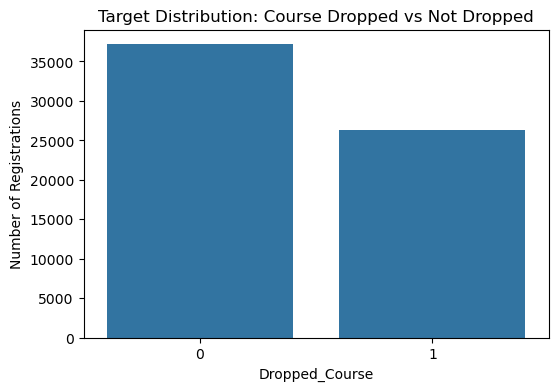

In [95]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x=TARGET_COL)
plt.title("Target Distribution: Course Dropped vs Not Dropped")
plt.xlabel("Dropped_Course")
plt.ylabel("Number of Registrations")
plt.show()

### Target insight

The dataset is not perfectly balanced: approximately 41.4% of registrations were cancelled and 58.6% were not cancelled.  
This is not an extreme imbalance, but it is still important to use ROC-AUC rather than relying only on accuracy.  
For the business problem, we care about ranking registrations by cancellation risk, because the company can prioritize operational intervention for the highest-risk cases.

## 4. Missing-Value Analysis

Missing values are not only a technical issue; they may contain business information.  
For example, a missing `Company_ID` or `Agent_ID` may indicate a different registration process, a less formal client relationship, or incomplete CRM data.  
Therefore, we analyze missingness before deciding how to impute it.

In [96]:
def missing_summary(df, name):
    summary = pd.DataFrame({
        "column": df.columns,
        f"{name}_missing_count": df.isna().sum().values,
        f"{name}_missing_pct": (df.isna().mean().values * 100).round(2),
        f"{name}_non_missing_count": df.notna().sum().values,
    })
    return summary.sort_values(f"{name}_missing_count", ascending=False)

train_missing = missing_summary(train_df, "train")
test_missing = missing_summary(test_df, "test")

train_missing.head(20)

,column,train_missing_count,train_missing_pct,train_non_missing_count
25,Company_ID,60344,95.08,3120
24,Agent_ID,11173,17.61,52291
7,Registration_Days_Before,2666,4.20,60798
11,Requested_Lab_Config,1736,2.74,61728
16,Physical_Course_Kits,1040,1.64,62424
19,Enrollment_Type,719,1.13,62745
22,Submission_Source,605,0.95,62859
26,Payment_Terms,587,0.92,62877
8,Origin_Country,557,0.88,62907
9,Catering_Package,407,0.64,63057


In [97]:
test_missing.head(20)

,column,test_missing_count,test_missing_pct,test_non_missing_count
25,Company_ID,15297,96.41,569
24,Agent_ID,2794,17.61,13072
7,Registration_Days_Before,642,4.05,15224
11,Requested_Lab_Config,477,3.01,15389
16,Physical_Course_Kits,227,1.43,15639
19,Enrollment_Type,177,1.12,15689
8,Origin_Country,160,1.01,15706
22,Submission_Source,149,0.94,15717
26,Payment_Terms,144,0.91,15722
9,Catering_Package,111,0.70,15755


In [98]:
missing_compare = train_missing.merge(
    test_missing,
    on="column",
    how="outer"
).fillna(0)

missing_compare = missing_compare[
    [
        "column",
        "train_missing_count",
        "train_missing_pct",
        "test_missing_count",
        "test_missing_pct",
    ]
].sort_values("train_missing_pct", ascending=False)

missing_compare

,column,train_missing_count,train_missing_pct,test_missing_count,test_missing_pct
5,Company_ID,60344,95.08,15297.0,96.41
0,Agent_ID,11173,17.61,2794.0,17.61
21,Registration_Days_Before,2666,4.20,642.0,4.05
22,Requested_Lab_Config,1736,2.74,477.0,3.01
14,Physical_Course_Kits,1040,1.64,227.0,1.43
9,Enrollment_Type,719,1.13,177.0,1.12
25,Submission_Source,605,0.95,149.0,0.94
13,Payment_Terms,587,0.92,144.0,0.91
12,Origin_Country,557,0.88,160.0,1.01
2,Catering_Package,407,0.64,111.0,0.70


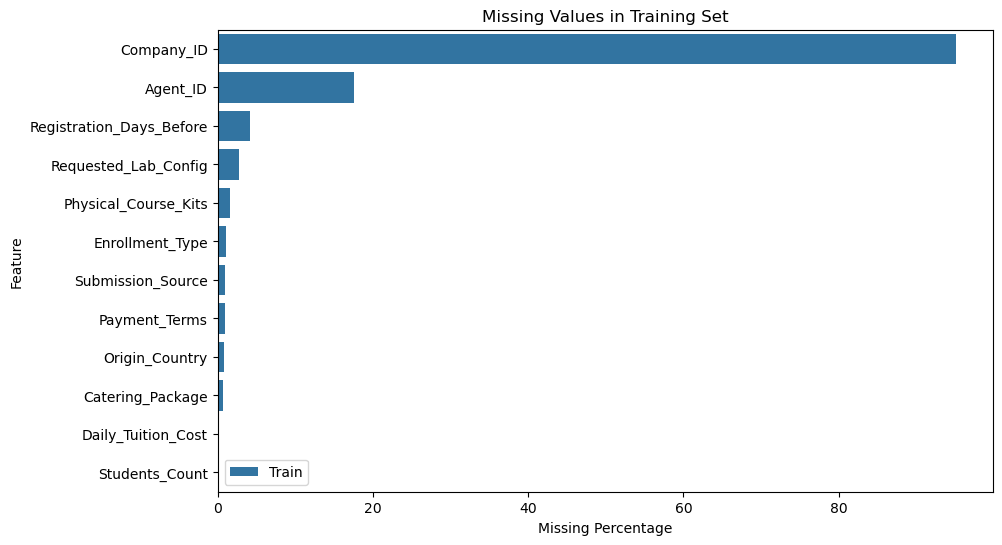

In [99]:
missing_plot_df = missing_compare[
    (missing_compare["train_missing_pct"] > 0) | 
    (missing_compare["test_missing_pct"] > 0)
].copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=missing_plot_df,
    x="train_missing_pct",
    y="column",
    label="Train"
)
plt.title("Missing Values in Training Set")
plt.xlabel("Missing Percentage")
plt.ylabel("Feature")
plt.show()

### Missing-value insight

The strongest missingness appears in `Company_ID`, which is missing in most rows, and `Agent_ID`, which is missing in a meaningful minority of rows.  
Several operational fields also contain missing values, including `Registration_Days_Before`, `Requested_Lab_Config`, `Physical_Course_Kits`, `Enrollment_Type`, `Submission_Source`, `Payment_Terms`, `Origin_Country`, `Catering_Package`, `Daily_Tuition_Cost`, and `Students_Count`.

Because missingness may reflect the way the registration was created or managed, we should not blindly delete these rows.  
Instead, we will later create missing-indicator features and use imputation strategies suitable for each feature type.

## 5. Missingness by Target

To check whether missing values are predictive, we compare the cancellation rate between rows where a feature is missing and rows where it is present.

In [100]:
missing_target_rows = []

for col in train_df.columns:
    if col in [ID_COL, TARGET_COL]:
        continue
    
    if train_df[col].isna().sum() > 0:
        temp = train_df.copy()
        temp[f"{col}_is_missing"] = temp[col].isna().astype(int)
        
        rates = temp.groupby(f"{col}_is_missing")[TARGET_COL].agg(["count", "mean"])
        
        missing_rate = rates.loc[1, "mean"] if 1 in rates.index else np.nan
        present_rate = rates.loc[0, "mean"] if 0 in rates.index else np.nan
        
        missing_target_rows.append({
            "feature": col,
            "missing_count": int(train_df[col].isna().sum()),
            "missing_dropout_rate": missing_rate,
            "present_dropout_rate": present_rate,
            "difference": missing_rate - present_rate
        })

missing_target_df = pd.DataFrame(missing_target_rows)
missing_target_df = missing_target_df.sort_values("difference", key=lambda s: s.abs(), ascending=False)

missing_target_df

,feature,missing_count,missing_dropout_rate,present_dropout_rate,difference
0,Students_Count,4,1.000000,0.414355,0.585645
9,Company_ID,60344,0.424848,0.212179,0.212668
11,Daily_Tuition_Cost,79,0.518987,0.414262,0.104725
8,Agent_ID,11173,0.335094,0.431336,-0.096243
10,Payment_Terms,587,0.354344,0.414953,-0.060609
7,Submission_Source,605,0.454545,0.414006,0.040540
3,Catering_Package,407,0.385749,0.414577,-0.028828
5,Physical_Course_Kits,1040,0.393269,0.414744,-0.021475
2,Origin_Country,557,0.432675,0.414231,0.018445
4,Requested_Lab_Config,1736,0.409562,0.414528,-0.004966


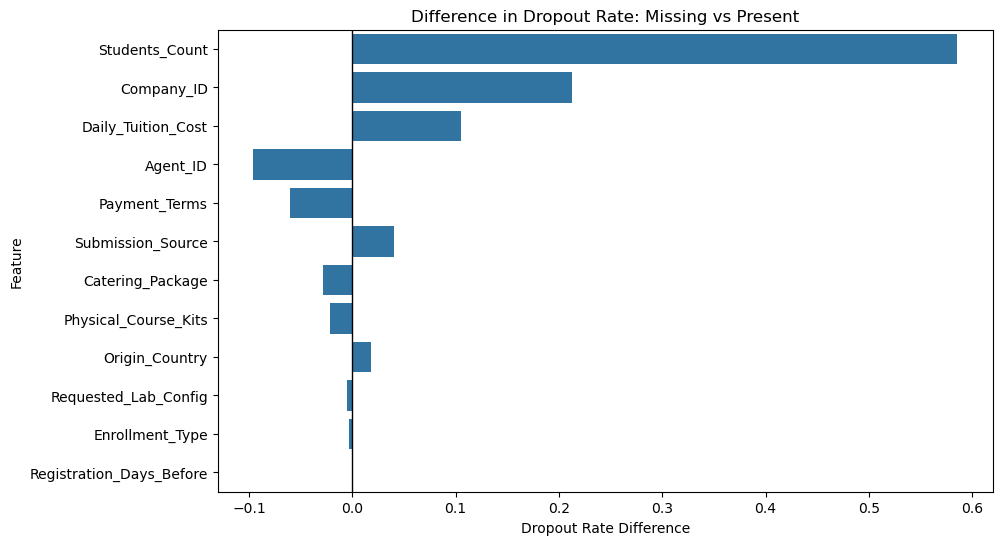

In [101]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=missing_target_df,
    x="difference",
    y="feature"
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Difference in Dropout Rate: Missing vs Present")
plt.xlabel("Dropout Rate Difference")
plt.ylabel("Feature")
plt.show()

### Missingness-by-target insight

If a feature has a large dropout-rate difference between missing and non-missing rows, the missingness itself may be informative.  
For these columns, simple imputation alone may hide useful signal.  
Therefore, in feature engineering we will add binary missing indicators for the most important missing columns before applying imputation.

## 6. Numeric Feature Analysis

In this section, we analyze the numerical features.  
The goal is to understand their distributions, detect skewness and outliers, and check how each numerical feature relates to the cancellation target.

This will later guide:
- outlier handling,
- feature transformations,
- feature engineering,
- and model choice.

In [102]:
numeric_features

['Professionals_Count',
 'Students_Count',
 'Observers_Count',
 'Practical_Hours',
 'Theory_Hours',
 'Registration_Days_Before',
 'Prev_Course_Dropouts',
 'Prev_Course_Attended',
 'Pre_Course_Supports_Tickets',
 'Physical_Course_Kits',
 'Waiting_List_Days',
 'Registration_Changes',
 'Returning_Client',
 'Agent_ID',
 'Company_ID',
 'Daily_Tuition_Cost']

In [103]:
numeric_summary = train_df[numeric_features].describe().T

numeric_summary["missing_count"] = train_df[numeric_features].isna().sum()
numeric_summary["missing_pct"] = (train_df[numeric_features].isna().mean() * 100).round(2)
numeric_summary["skewness"] = train_df[numeric_features].skew(numeric_only=True).round(3)

numeric_summary

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_pct,skewness
Professionals_Count,63464.0,1.835214,0.508607,0.0,2.0,2.0,2.0,4.0,0,0.00,-0.474
Students_Count,63460.0,8.751718,294.238584,0.0,0.0,0.0,0.0,9999.0,4,0.01,33.924
Observers_Count,63464.0,0.005326,0.089662,0.0,0.0,0.0,0.0,10.0,0,0.00,45.379
Practical_Hours,63464.0,6.609054,215.502929,-5.0,0.0,1.0,1.0,10000.0,0,0.00,40.450
Theory_Hours,63464.0,2.164392,1.469854,0.0,1.0,2.0,3.0,41.0,0,0.00,3.354
Registration_Days_Before,60798.0,102.894470,109.178824,0.0,19.0,65.0,150.0,629.0,2666,4.20,1.497
Prev_Course_Dropouts,63464.0,0.095991,0.448526,0.0,0.0,0.0,0.0,21.0,0,0.00,15.704
Prev_Course_Attended,63464.0,0.122967,1.535201,0.0,0.0,0.0,0.0,61.0,0,0.00,21.956
Pre_Course_Supports_Tickets,63464.0,0.513330,0.763563,0.0,0.0,0.0,1.0,5.0,0,0.00,1.466
Physical_Course_Kits,62424.0,0.026224,0.160202,0.0,0.0,0.0,0.0,3.0,1040,1.64,6.000


### Numeric summary insight

The numeric summary helps identify features with different scales, missing values, skewed distributions, and possible outliers.  
Features such as participant counts, registration timing, support tickets, registration changes, and tuition cost may contain useful operational signals about cancellation risk.

Large differences in scale also mean that linear models will require scaling, while tree-based models such as LightGBM/XGBoost are less sensitive to feature scaling.

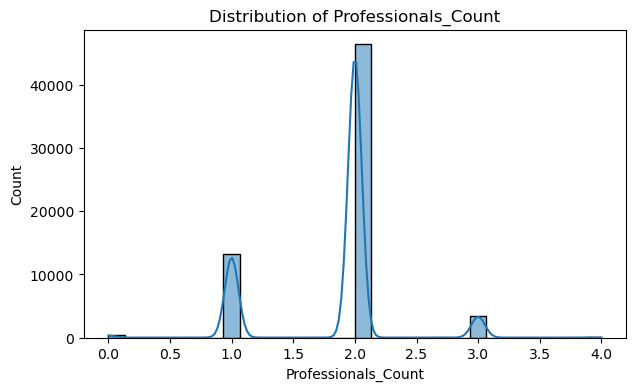

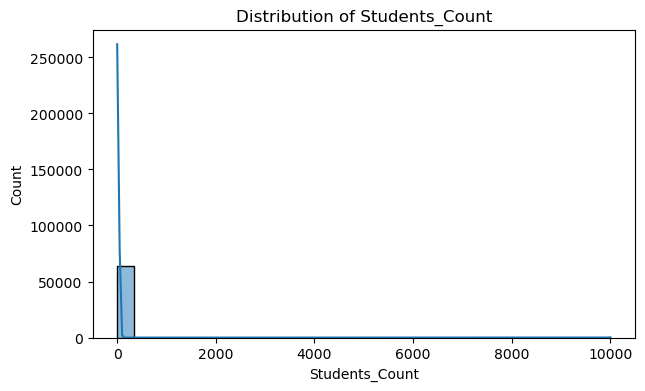

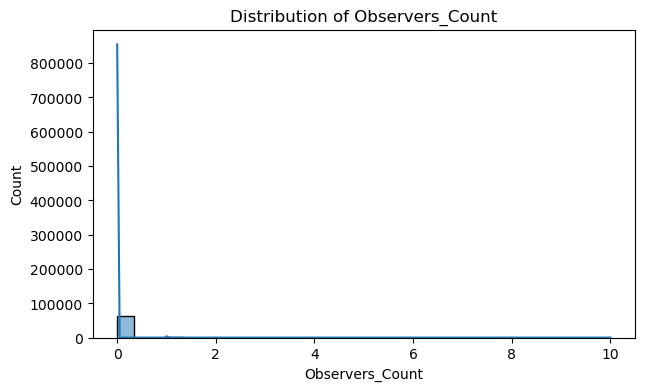

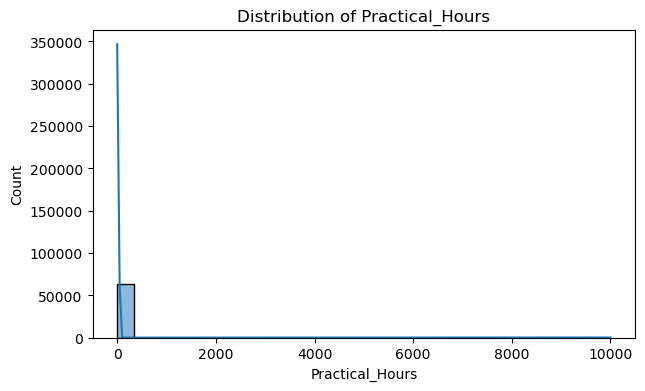

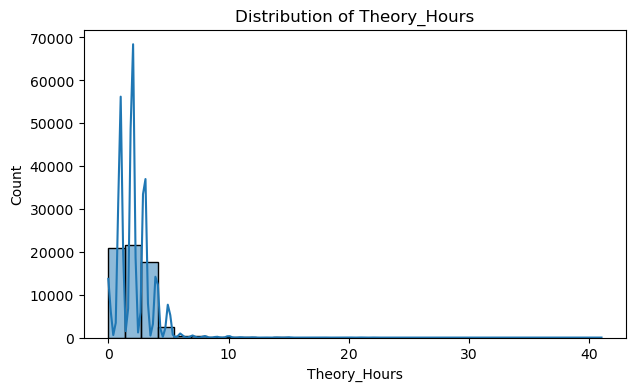

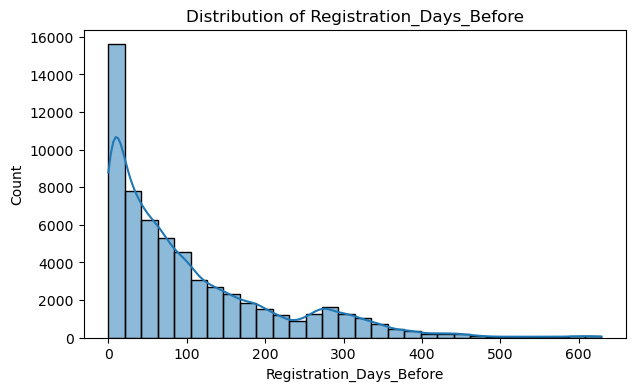

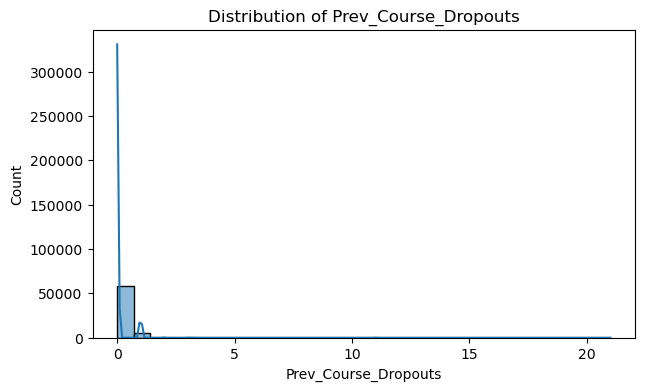

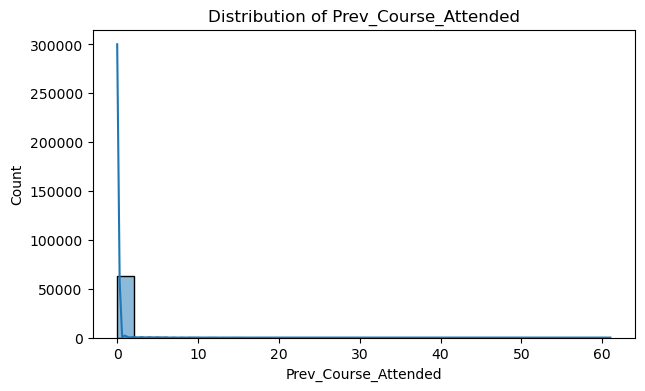

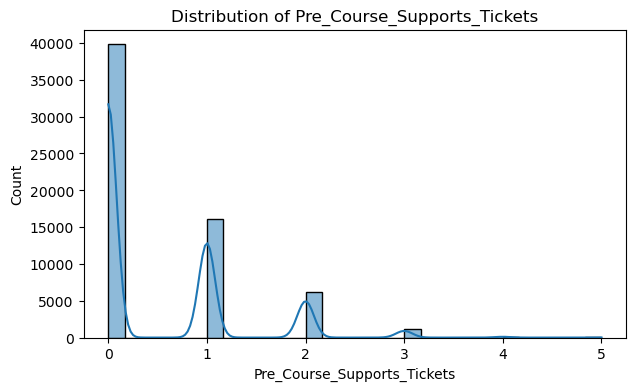

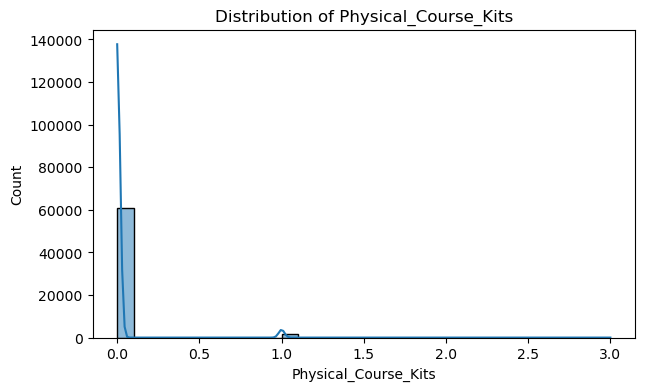

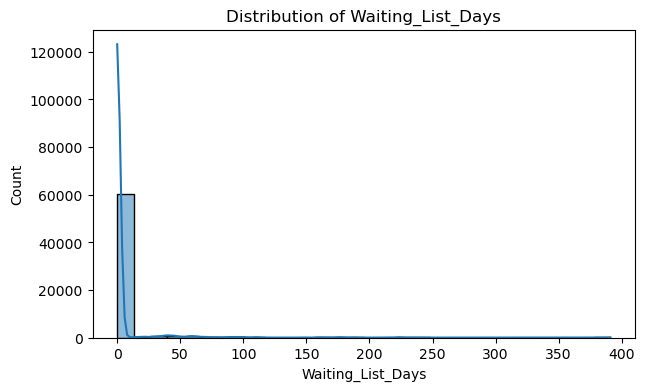

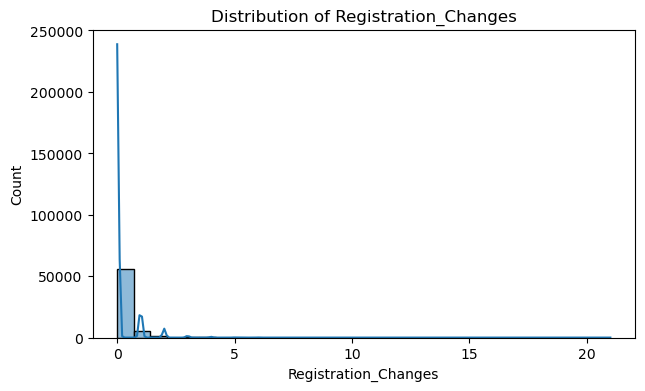

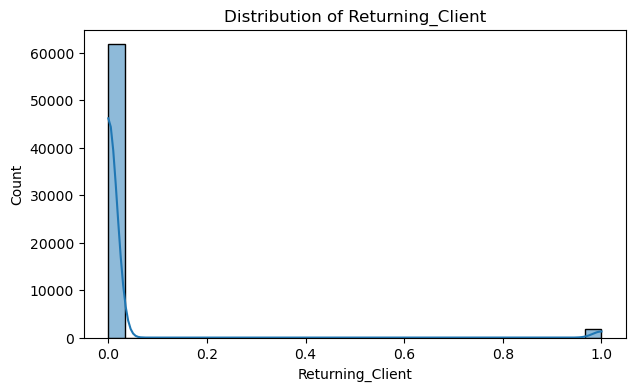

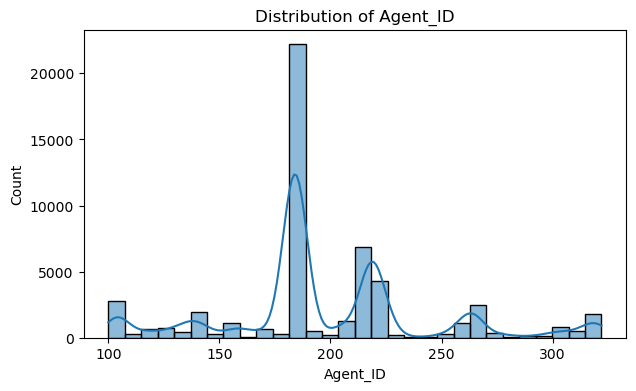

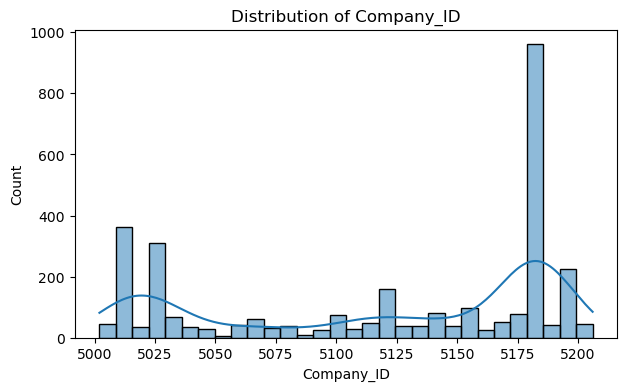

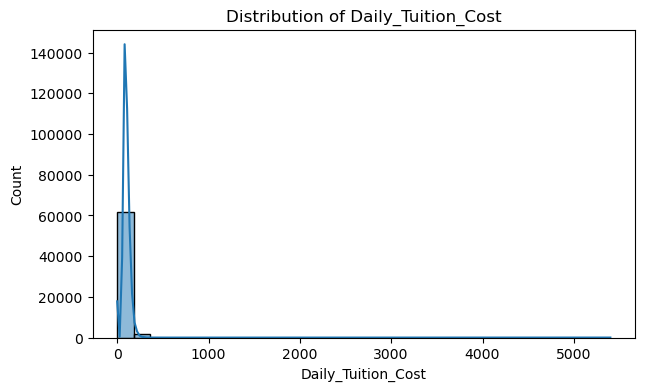

In [104]:
for col in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(train_df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

### Numerical features by target

We now compare each numerical feature between cancelled and non-cancelled registrations.  
This helps identify features whose distributions differ between the two target classes.

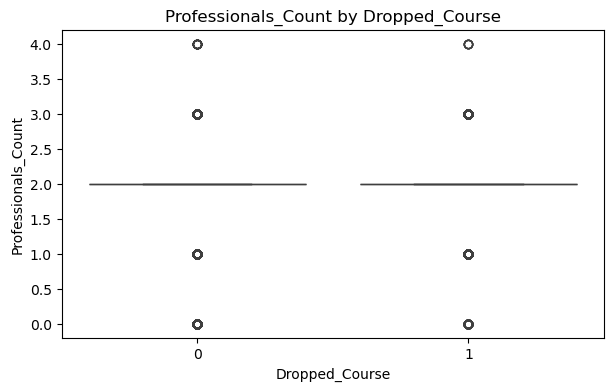

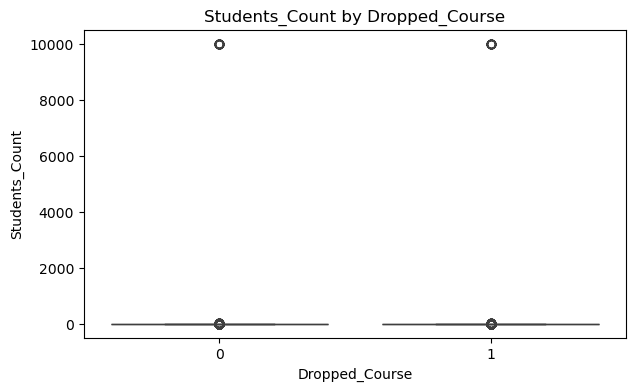

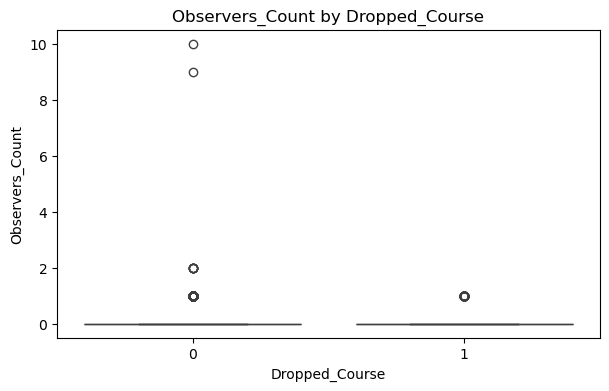

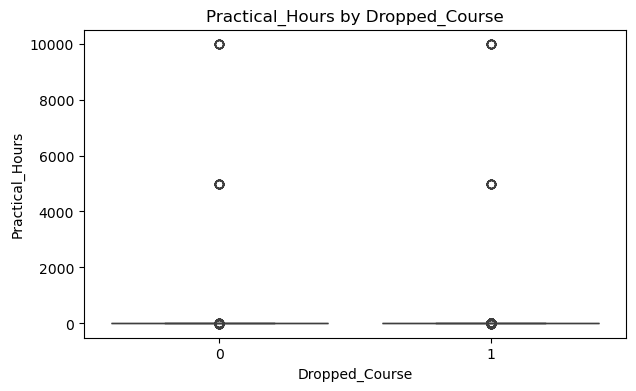

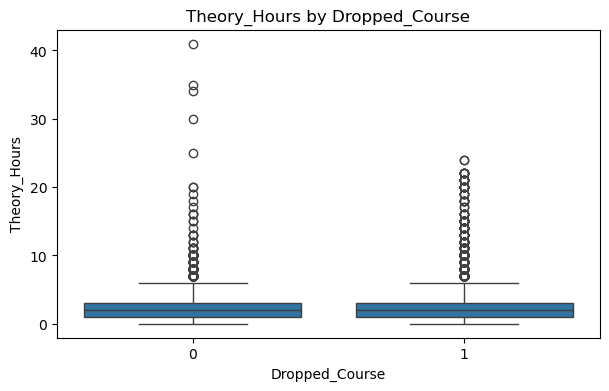

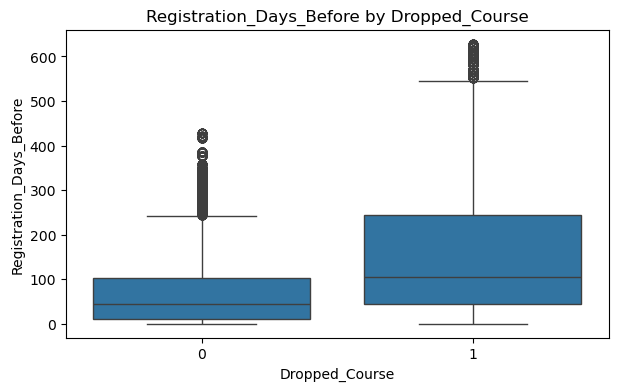

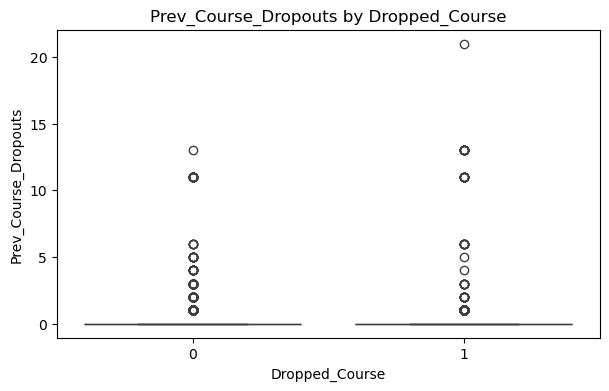

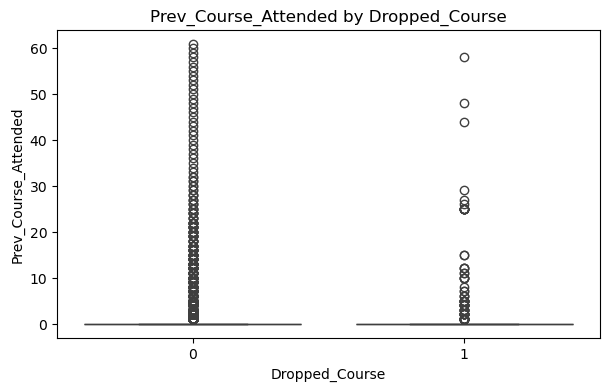

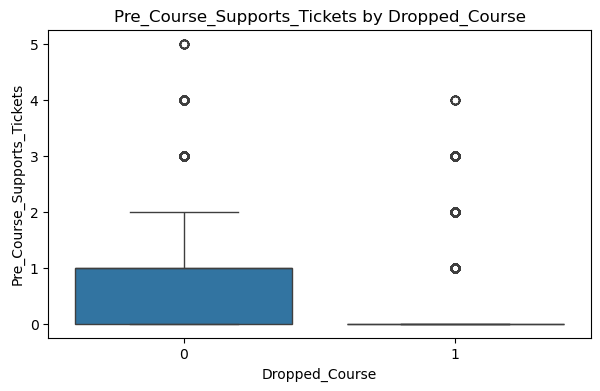

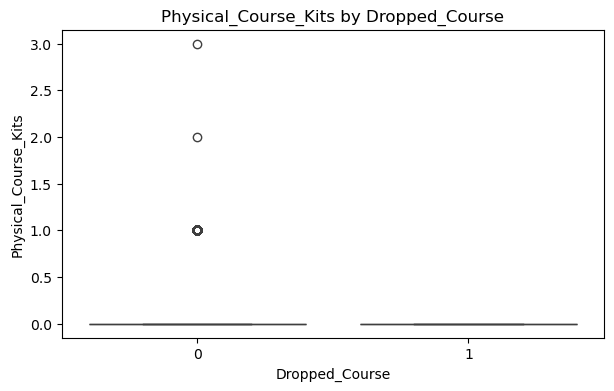

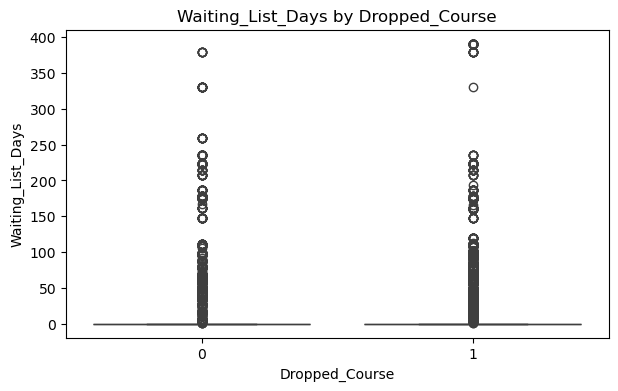

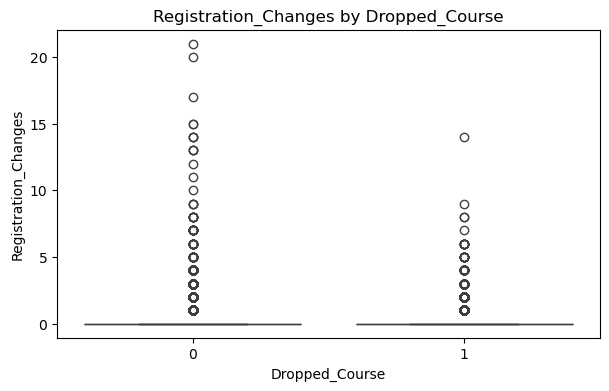

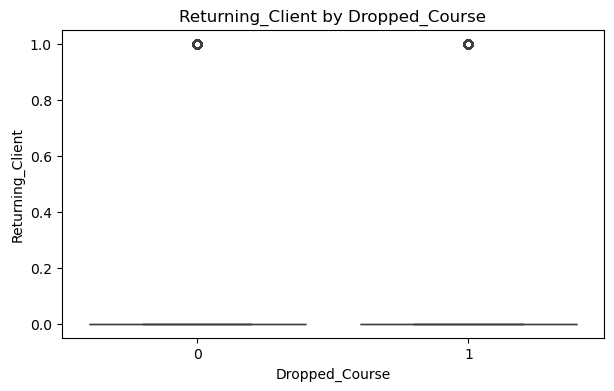

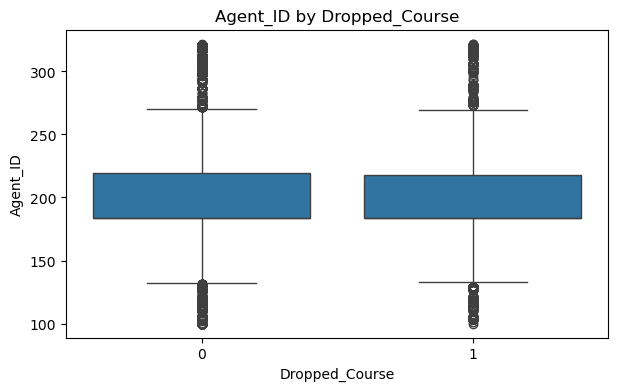

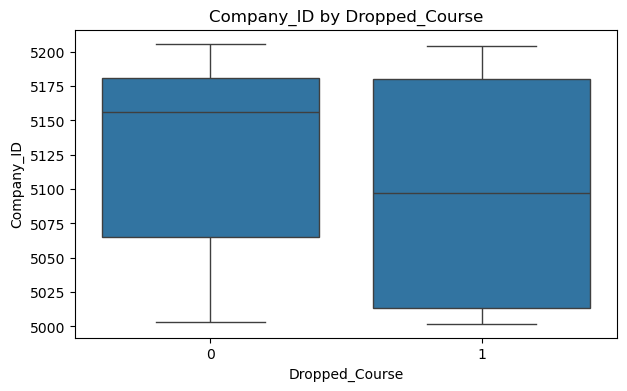

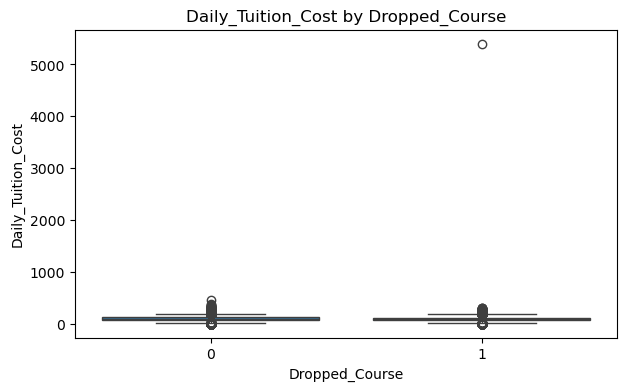

In [105]:
for col in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=train_df, x=TARGET_COL, y=col)
    plt.title(f"{col} by Dropped_Course")
    plt.xlabel("Dropped_Course")
    plt.ylabel(col)
    plt.show()

In [106]:
corr_with_target = (
    train_df[numeric_features + [TARGET_COL]]
    .corr(numeric_only=True)[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr_with_target_df = corr_with_target.reset_index()
corr_with_target_df.columns = ["feature", "correlation_with_target"]

corr_with_target_df

,feature,correlation_with_target
0,Registration_Days_Before,0.351210
1,Pre_Course_Supports_Tickets,-0.301284
2,Company_ID,-0.206826
3,Prev_Course_Dropouts,0.199148
4,Registration_Changes,-0.147731
5,Physical_Course_Kits,-0.137800
6,Agent_ID,0.074423
7,Waiting_List_Days,0.067626
8,Returning_Client,-0.059177
9,Professionals_Count,0.056772


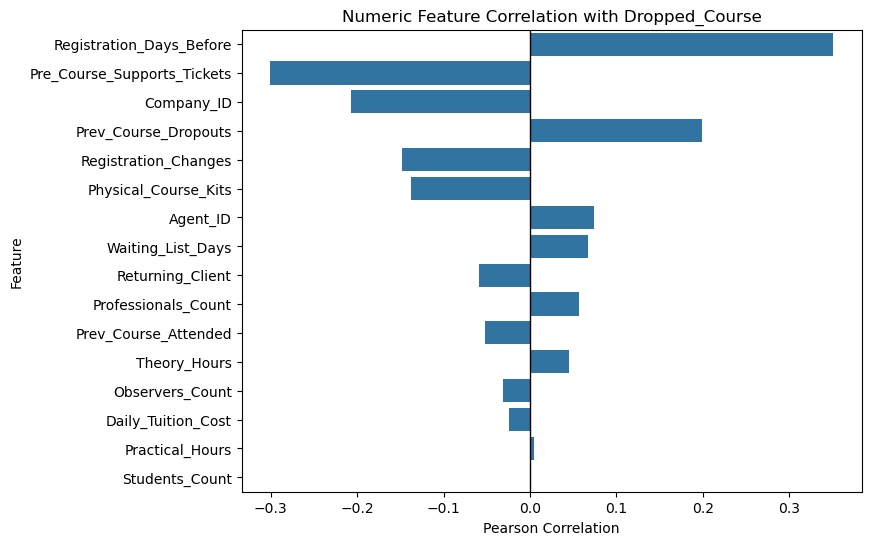

In [107]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=corr_with_target_df,
    x="correlation_with_target",
    y="feature"
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Numeric Feature Correlation with Dropped_Course")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.show()

### Correlation insight

Pearson correlation captures only linear relationships, so a low correlation does not mean a feature is useless.  
This is especially important for tree-based models, which can capture nonlinear effects and interactions.

Therefore, correlation is used here as an exploratory tool, not as the only feature-selection criterion.

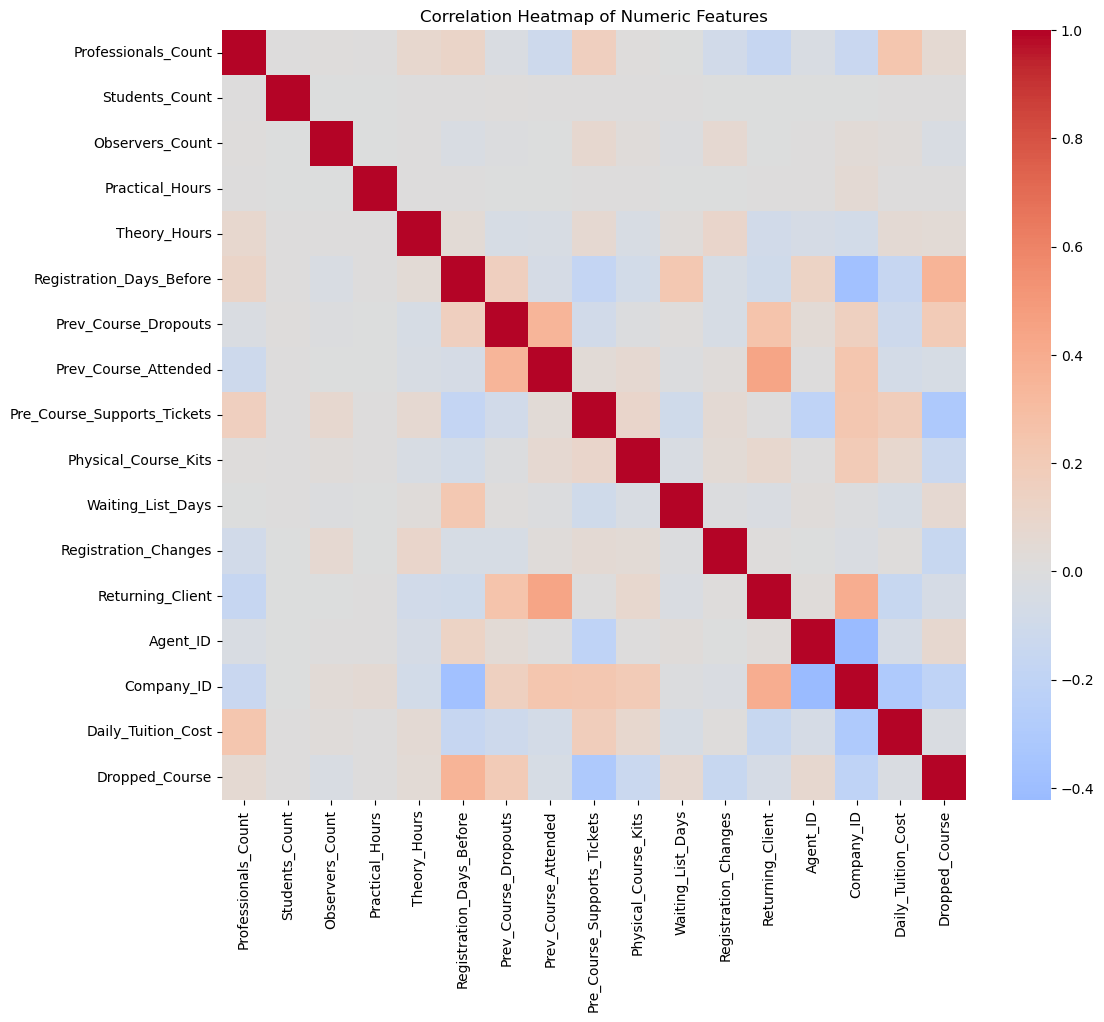

In [89]:
plt.figure(figsize=(12, 10))
corr_matrix = train_df[numeric_features + [TARGET_COL]].corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

### Correlation heatmap insight

The heatmap helps identify redundant or highly related numerical features.  
Highly correlated features are not necessarily harmful for tree-based models, but they may increase noise or variance for some models.  
This will be considered later during feature selection and bias-variance analysis.